In [259]:
import pandas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import sklearn.model_selection as m

import sklearn


np.set_printoptions(precision=3)

In [260]:
!pip install yellowbrick



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [261]:
df = pd.read_csv('../data/raw/diabetes.csv')

In [262]:
df.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


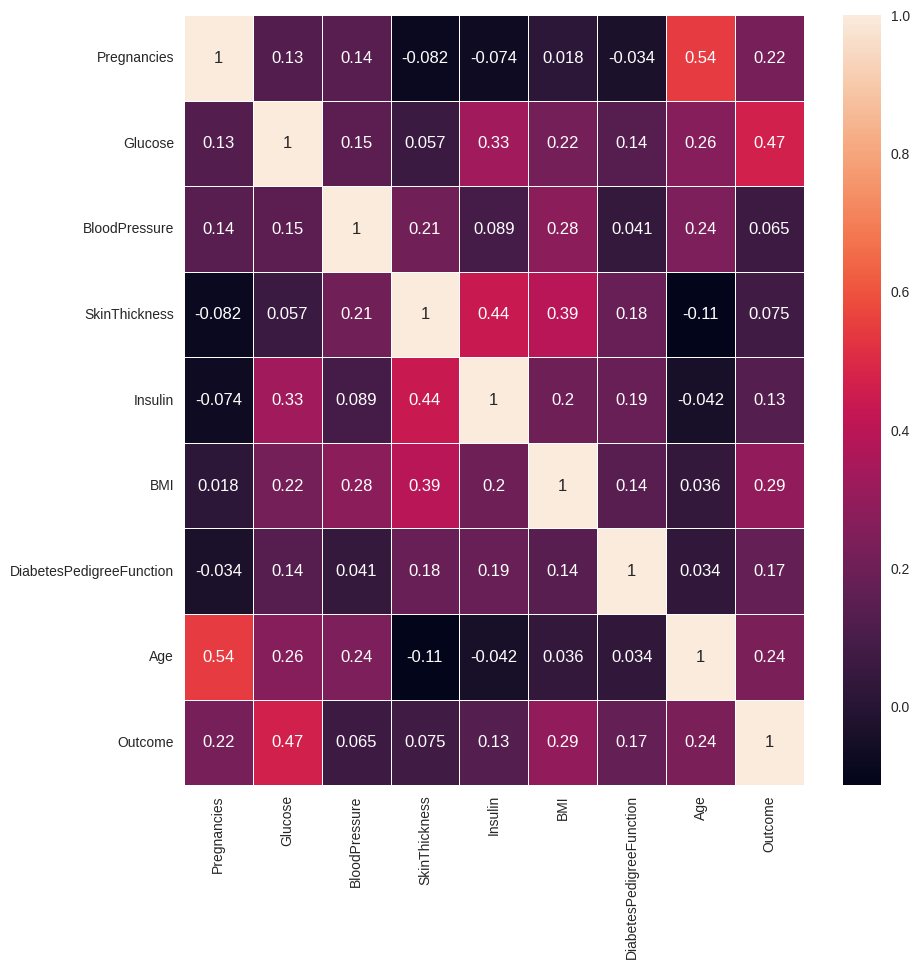

In [263]:
fig, ax = plt.subplots(figsize=(10, 10))

sns.heatmap(df.corr(), annot=True, linewidths=.5, ax=ax)

plt.show()

In [264]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [265]:
%lsmagic

Available line magics:
%alias  %alias_magic  %autoawait  %autocall  %automagic  %autosave  %bookmark  %cat  %cd  %clear  %code_wrap  %colors  %conda  %config  %connect_info  %cp  %debug  %dhist  %dirs  %doctest_mode  %ed  %edit  %env  %gui  %hist  %history  %killbgscripts  %ldir  %less  %lf  %lk  %ll  %load  %load_ext  %loadpy  %logoff  %logon  %logstart  %logstate  %logstop  %ls  %lsmagic  %lx  %macro  %magic  %mamba  %man  %matplotlib  %micromamba  %mkdir  %more  %mv  %notebook  %page  %pastebin  %pdb  %pdef  %pdoc  %pfile  %pinfo  %pinfo2  %pip  %popd  %pprint  %precision  %prun  %psearch  %psource  %pushd  %pwd  %pycat  %pylab  %qtconsole  %quickref  %recall  %rehashx  %reload_ext  %rep  %rerun  %reset  %reset_selective  %rm  %rmdir  %run  %save  %sc  %set_env  %store  %sx  %system  %tb  %time  %timeit  %unalias  %unload_ext  %uv  %who  %who_ls  %whos  %xdel  %xmode

Available cell magics:
%%!  %%HTML  %%SVG  %%bash  %%capture  %%code_wrap  %%debug  %%file  %%html  %%javascript  %%

In [266]:
%matplotlib inline


In [267]:
import matplotlib
matplotlib.use("module://ipykernel.pylab.backend_inline")

In [268]:
X = df[["Insulin", "BMI", "BloodPressure", "DiabetesPedigreeFunction"]]
y = df["Age"]

In [269]:
feature_names = X.columns.to_list()

In [270]:
from yellowbrick.target import FeatureCorrelation

In [271]:
visualizer = FeatureCorrelation(labels=feature_names, method="pearson") # spr te metody

In [272]:
visualizer.fit(X, y)

,ax,<Axes: >
,method,'pearson'
,labels,"['Insulin', 'BMI', ...]"
,sort,False
,feature_index,None
,feature_names,None
,color,None


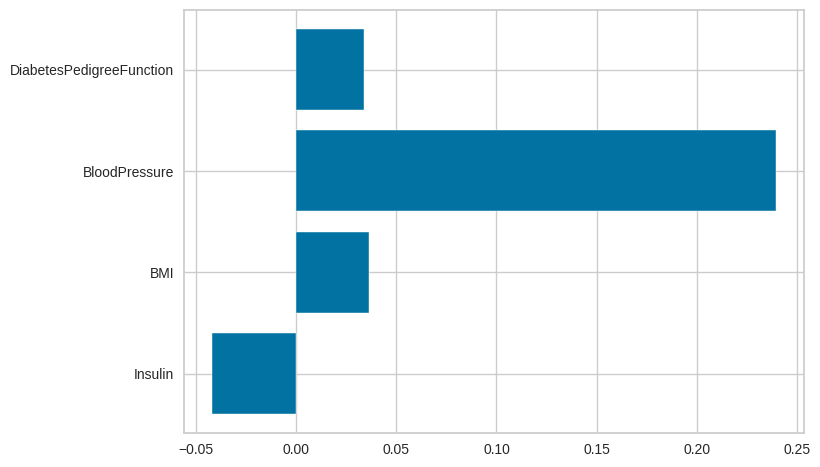

In [273]:
ax = visualizer.ax
plt.sca(ax)
plt.show()

In [274]:
visualizer.scores_

array([-0.042,  0.036,  0.24 ,  0.034])

In [275]:
visualizer.features_

array(['Insulin', 'BMI', 'BloodPressure', 'DiabetesPedigreeFunction'],
      dtype='<U24')

In [276]:
df_ = pd.DataFrame({"feature_names": visualizer.features_, "scores": visualizer.scores_})

In [277]:
df_

,feature_names,scores
0,Insulin,-0.042163
1,BMI,0.036242
2,BloodPressure,0.239528
3,DiabetesPedigreeFunction,0.033561


In [278]:
X = df.drop(columns=["Outcome"])
y = df["Outcome"]

In [279]:
feature_names = X.columns.to_list()
feature_names

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age']

In [280]:
visualizer = FeatureCorrelation(labels=feature_names, method="pearson")

In [281]:
visualizer.fit(X, y)

,ax,<Axes: >
,method,'pearson'
,labels,"['Pregnancies', 'Glucose', ...]"
,sort,False
,feature_index,None
,feature_names,None
,color,None


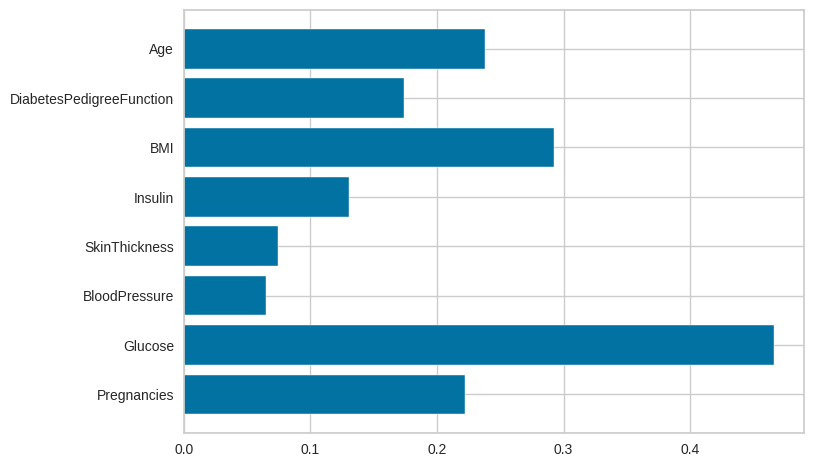

In [282]:
ax = visualizer.ax
plt.sca(ax)
plt.show()

In [283]:
discreet_features = [False for _ in feature_names]
discreet_features

[False, False, False, False, False, False, False, False]

In [284]:
discreet_features[0] = True
discreet_features

[True, False, False, False, False, False, False, False]

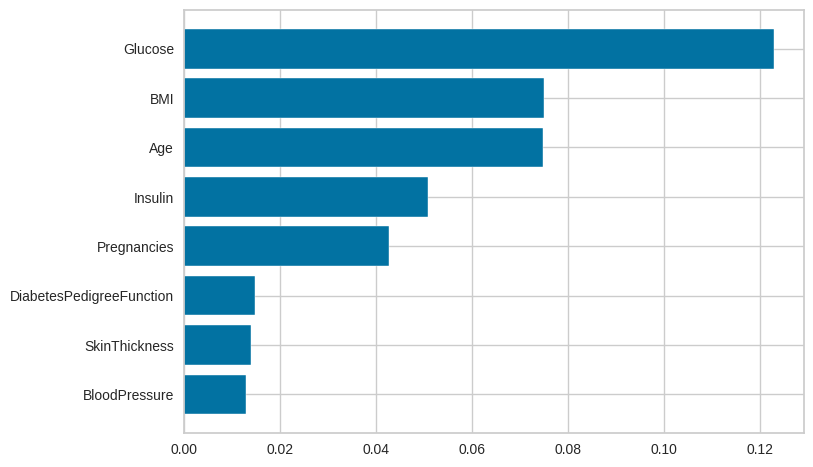

In [285]:
visualizer = FeatureCorrelation(labels=feature_names, method="mutual_info-classification", sort=True)
visualizer.fit(X, y, discrete_features=discreet_features, random_state=42)
ax = visualizer.ax
plt.sca(ax)
plt.show()

In [286]:
visualizer.scores_

array([0.013, 0.014, 0.015, 0.043, 0.051, 0.075, 0.075, 0.123])

# Correlation

In [287]:
df = pd.read_csv("../data/interim/cars_processed.csv")

In [288]:
df

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Origin,Age
0,18.000000,8,307.0,130,3504,12.0,US,53
1,16.000000,8,304.0,150,3433,12.0,US,53
2,17.000000,8,302.0,140,3449,10.5,US,53
3,14.000000,8,454.0,220,4354,9.0,US,53
4,23.551429,8,440.0,215,4312,8.5,US,53
...,...,...,...,...,...,...,...,...
382,27.000000,4,140.0,86,2790,15.6,US,41
383,44.000000,4,97.0,52,2130,24.6,Europe,41
384,32.000000,4,135.0,84,2295,11.6,US,41
385,28.000000,4,120.0,79,2625,18.6,US,41


In [289]:
from sklearn.preprocessing import scale

In [290]:
# df[["Cylinders"]] = scale(df[["Cylinders"]].astype("float64"))

In [291]:
df_numeric = df.select_dtypes(include='number').drop(columns=["MPG"])

In [292]:
df_numeric.columns


Index(['Cylinders', 'Displacement', 'Horsepower', 'Weight', 'Acceleration',
       'Age'],
      dtype='object')

In [293]:
for feature in df_numeric.columns:
    df[[feature]] = scale(df[[feature]].astype("float64"))

In [294]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
MPG,387.0,2.367251e+01,7.736579,9.000000,17.600000,23.200000,29.000000,46.600000
Cylinders,387.0,3.672055e-17,1.001294,-1.447404,-0.847034,-0.847034,0.353707,1.554447
Displacement,387.0,1.101617e-16,1.001294,-1.199046,-0.865937,-0.445929,0.654779,2.537570
Horsepower,387.0,1.101617e-16,1.001294,-1.513838,-0.752271,-0.305835,0.455733,3.318176
Weight,387.0,1.101617e-16,1.001294,-1.600007,-0.880092,-0.207501,0.738386,2.572779
Acceleration,387.0,2.203233e-16,1.001294,-2.761372,-0.610215,-0.026851,0.538284,3.363956
Age,387.0,8.078522e-16,1.001294,-1.615000,-0.796216,0.022568,0.841351,1.660135


In [295]:
X = df[df_numeric.columns]
y = df["MPG"]
X

,Cylinders,Displacement,Horsepower,Weight,Acceleration,Age
0,1.554447,1.108580,0.692081,0.637231,-1.302961,1.660135
1,1.554447,1.079614,1.217300,0.553231,-1.302961,1.660135
2,1.554447,1.060303,0.954691,0.572161,-1.849865,1.660135
3,1.554447,2.527915,3.055566,1.642864,-2.396769,1.660135
4,1.554447,2.392740,2.924262,1.593174,-2.579071,1.660135
...,...,...,...,...,...,...
382,-0.847034,-0.503862,-0.463401,-0.207501,0.009610,-1.615000
383,-0.847034,-0.919041,-1.356273,-0.988345,3.291036,-1.615000
384,-0.847034,-0.552138,-0.515922,-0.793134,-1.448802,-1.615000
385,-0.847034,-0.696968,-0.647227,-0.402712,1.103418,-1.615000


In [296]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
linear_regression = LinearRegression()
linear_regression.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [297]:
y_pred = linear_regression.predict(X_test)

In [298]:
from sklearn.metrics import r2_score

In [299]:
r2_score(y_test, y_pred)

0.7062023738384152

In [300]:
def adjusted_r2(r_square, labels, features):
    return 1 - ((1 - r_square) * (len(labels) - 1) / (len(labels) - features.shape[1] - 1))

In [301]:
adjusted_r2(r2_score(y_test, y_pred), y_test, X_test)

0.681374405430394

In [302]:
X.corr()

,Cylinders,Displacement,Horsepower,Weight,Acceleration,Age
Cylinders,1.000000,0.922633,0.811466,0.873029,-0.458161,0.321850
Displacement,0.922633,1.000000,0.894199,0.932822,-0.526901,0.357047
Horsepower,0.811466,0.894199,1.000000,0.863388,-0.670920,0.404458
Weight,0.873029,0.932822,0.863388,1.000000,-0.397181,0.299049
Acceleration,-0.458161,-0.526901,-0.670920,-0.397181,1.000000,-0.292705
Age,0.321850,0.357047,0.404458,0.299049,-0.292705,1.000000


In [303]:
abs(X.corr()) > 0.8

,Cylinders,Displacement,Horsepower,Weight,Acceleration,Age
Cylinders,True,True,True,True,False,False
Displacement,True,True,True,True,False,False
Horsepower,True,True,True,True,False,False
Weight,True,True,True,True,False,False
Acceleration,False,False,False,False,True,False
Age,False,False,False,False,False,True


In [304]:
trimmed_X = X.drop(columns=["Cylinders", "Displacement", "Weight"])

In [305]:
trimmed_X.corr()

,Horsepower,Acceleration,Age
Horsepower,1.000000,-0.670920,0.404458
Acceleration,-0.670920,1.000000,-0.292705
Age,0.404458,-0.292705,1.000000


In [306]:
X_train, X_test, y_train, y_test = train_test_split(trimmed_X, y, test_size=0.2)

linear_regression = LinearRegression()
linear_regression.fit(X_train, y_train)
y_pred = linear_regression.predict(X_test)
r2_score(y_test, y_pred)


0.6899420012877435

In [307]:
r2 = adjusted_r2(r2_score(y_test, y_pred), y_test, X_test)
r2

0.6773720824210304

In [308]:
trimmed_X["Displacement"] = X["Displacement"]

In [309]:
X_train, X_test, y_train, y_test = train_test_split(trimmed_X, y, test_size=0.2)

linear_regression = LinearRegression()
linear_regression.fit(X_train, y_train)
y_pred = linear_regression.predict(X_test)
r_2 = r2_score(y_test, y_pred)

r2_adjusted = adjusted_r2(r2_score(y_test, y_pred), y_test, X_test)


In [310]:
print(r2, r2_adjusted)

0.6773720824210304 0.766316011144293


In [311]:
trimmed_X["Cylinders"] = X["Cylinders"]

In [312]:
X_train, X_test, y_train, y_test = train_test_split(trimmed_X, y, test_size=0.2)

linear_regression = LinearRegression()
linear_regression.fit(X_train, y_train)
y_pred = linear_regression.predict(X_test)
r_2 = r2_score(y_test, y_pred)

r2_adjusted = adjusted_r2(r2_score(y_test, y_pred), y_test, X_test)

print(r2, r2_adjusted)

0.6773720824210304 0.6636081512709753


### VIF - Variance Inflation Factor